# 任务二：比较不同激活函数的影响

这个任务的目标不是重新设计一个更复杂的网络，
而是在“其他条件都尽量保持不变”的前提下，只比较激活函数不同会带来什么变化。

这次我们固定下面这些条件：

- 数据集：Fashion-MNIST
- 网络结构：`784 -> 256 -> 10`
- 优化器：Adam
- 学习率：0.001
- 训练轮数：20
- batch size：64

唯一变化的是隐藏层激活函数：

- ReLU
- Sigmoid
- Tanh

整个实验可以理解成下面 7 步：

1. 导入库并设置实验环境。
2. 加载 Fashion-MNIST，并划分训练集、验证集、测试集。
3. 定义可以切换激活函数的 MLP。
4. 定义训练和验证函数。
5. 分别训练 ReLU、Sigmoid、Tanh 三组模型。
6. 整理对比结果表。
7. 绘制曲线，观察收敛速度、最高验证准确率和训练稳定性。


## 第 1 步：导入库并设置实验环境

这一格和任务一很像，因为基础环境是相同的。

这里需要特别记住 3 个点：

- `ACTIVATION_FACTORIES`
  用一个字典把 3 种激活函数统一管理起来，后面循环训练时很方便。
- `RANDOM_SEED`
  固定随机种子，让 3 组实验尽量在同样条件下比较。
- `NUM_EPOCHS = 20`
  这次比较实验还是按题目要求训练 20 轮。


In [1]:
import warnings
warnings.filterwarnings("ignore")

import copy
import random
import time
from pathlib import Path
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
HIDDEN_DIM = 256
VALID_RATIO = 0.1

# 这次任务只更换隐藏层激活函数
ACTIVATION_FACTORIES = {
    "ReLU": nn.ReLU,
    "Sigmoid": nn.Sigmoid,
    "Tanh": nn.Tanh,
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 第 2 步：准备数据

这一步和任务一基本一样，因为我们比较的是激活函数，不是换数据。

还是使用：

- 训练集：Fashion-MNIST 原始训练集
- 验证集：从训练集中划出 10%
- 测试集：Fashion-MNIST 原始测试集

这样做的目的，是保证三组实验都在同样的数据条件下比较，结果才公平。


### 这一格最关键的理解

为什么任务二还保留测试集？

虽然题目重点要求比较的是验证集表现，
但保留测试集可以帮助我们在最后看一下：
哪种激活函数在最终测试数据上也表现更稳。

不过这次分析的重点，还是：

- 前期损失下降速度快不快
- 验证集最高准确率谁更高
- 曲线是否平滑稳定


In [2]:
def build_dataloaders(data_root: Path):
    # ToTensor() 会自动把像素值从 [0, 255] 缩放到 [0, 1]
    transform = transforms.ToTensor()

    train_full = datasets.FashionMNIST(
        root=str(data_root),
        train=True,
        transform=transform,
        download=False,
    )
    test_dataset = datasets.FashionMNIST(
        root=str(data_root),
        train=False,
        transform=transform,
        download=False,
    )

    valid_size = int(len(train_full) * VALID_RATIO)
    train_size = len(train_full) - valid_size
    split_generator = torch.Generator().manual_seed(RANDOM_SEED)
    train_dataset, valid_dataset = random_split(
        train_full,
        [train_size, valid_size],
        generator=split_generator,
    )

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": 0,
        "pin_memory": torch.cuda.is_available(),
    }

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)
    return train_loader, valid_loader, test_loader


set_seed(RANDOM_SEED)
device = get_device()
data_root = Path.cwd() / "fashion_mnist"

train_loader, valid_loader, test_loader = build_dataloaders(data_root)

print("当前设备：", device)
print("数据目录：", data_root)
print("对比激活函数：", list(ACTIVATION_FACTORIES.keys()))
print(f"训练集批次数：{len(train_loader)}")
print(f"验证集批次数：{len(valid_loader)}")
print(f"测试集批次数：{len(test_loader)}")


当前设备： cuda
数据目录： C:\Users\qintian\Desktop\人工智能\实验三_发送版\fashion_mnist
对比激活函数： ['ReLU', 'Sigmoid', 'Tanh']
训练集批次数：844
验证集批次数：94
测试集批次数：157


## 第 3 步：定义可以切换激活函数的 MLP

任务二的关键在这里。

和任务一相比，网络结构没有变，还是：

`784 -> 256 -> 10`

但现在隐藏层激活函数不再写死成 `ReLU()`，
而是变成一个可以传进来的参数。

也就是说，这个模型模板是一样的，
真正不同的地方只在这一行：

`activation_cls()`

如果传的是 `nn.ReLU`，那就用 ReLU；
如果传的是 `nn.Sigmoid`，那就用 Sigmoid；
如果传的是 `nn.Tanh`，那就用 Tanh。


### 为什么这样写更适合做对比实验

因为我们想保证：

- 输入层不变
- 隐藏层神经元数不变
- 输出层不变
- 优化器不变
- 学习率不变

只有激活函数变。

这样最后的差异，才更能说明“激活函数本身”的影响。


In [3]:
class ActivationMLP(nn.Module):
    def __init__(self, activation_cls, hidden_dim: int = HIDDEN_DIM, num_classes: int = 10) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            activation_cls(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# 先随便用 ReLU 试着创建一个模型，看看结构是否正确
demo_model = ActivationMLP(activation_cls=nn.ReLU)
print(demo_model)


ActivationMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 第 4 步：定义训练和验证函数

这一部分和任务一思路一样。

我们还是拆成两个函数：

- `run_one_epoch()`：负责一轮训练或验证
- `train_model()`：负责训练某一种激活函数对应的模型

这次 `train_model()` 比任务一多了一个参数：

- `activation_name`
  用来记录当前正在训练的是哪一种激活函数
- `activation_cls`
  真正传给模型使用的激活函数类


In [4]:
def run_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: Optional[torch.optim.Optimizer] = None,
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def train_model(
    activation_name: str,
    activation_cls,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[nn.Module, pd.DataFrame]:
    # 为了让三组实验更公平，每次训练前都重置随机种子
    set_seed(RANDOM_SEED)

    model = ActivationMLP(activation_cls=activation_cls).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = []
    best_state_dict = copy.deepcopy(model.state_dict())
    best_valid_acc = 0.0

    print(f"\n========== 开始训练：{activation_name} ==========")

    for epoch in range(1, NUM_EPOCHS + 1):
        start_time = time.time()

        train_loss, train_acc = run_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )
        valid_loss, valid_acc = run_one_epoch(
            model=model,
            dataloader=valid_loader,
            criterion=criterion,
            optimizer=None,
            device=device,
        )

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_state_dict = copy.deepcopy(model.state_dict())

        epoch_seconds = time.time() - start_time
        history.append(
            {
                "activation": activation_name,
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "valid_loss": valid_loss,
                "valid_accuracy": valid_acc,
                "seconds": epoch_seconds,
            }
        )

        print(
            f"{activation_name} | Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f} | "
            f"time={epoch_seconds:.2f}s"
        )

    model.load_state_dict(best_state_dict)
    return model, pd.DataFrame(history)


## 第 5 步：开始做三组对比实验

这一格就是任务二的核心部分。

我们会依次训练：

- ReLU
- Sigmoid
- Tanh

并且把每一种激活函数的训练记录都单独保存下来。

这里要重点看的是：

- 前几轮损失下降得快不快
- 验证集准确率最高能到多少
- 曲线是否平滑，有没有明显抖动


In [5]:
def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    return run_one_epoch(
        model=model,
        dataloader=dataloader,
        criterion=criterion,
        optimizer=None,
        device=device,
    )


histories = {}
test_results = {}
criterion = nn.CrossEntropyLoss()

for activation_name, activation_cls in ACTIVATION_FACTORIES.items():
    model, history_df = train_model(
        activation_name=activation_name,
        activation_cls=activation_cls,
        train_loader=train_loader,
        valid_loader=valid_loader,
        criterion=criterion,
        device=device,
    )
    histories[activation_name] = history_df
    test_results[activation_name] = evaluate_model(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=device,
    )



========== 开始训练：ReLU ==========
ReLU | Epoch 01/20 | train_loss=0.5391, train_acc=0.8104 | valid_loss=0.4178, valid_acc=0.8558 | time=3.27s
ReLU | Epoch 02/20 | train_loss=0.3912, train_acc=0.8600 | valid_loss=0.3934, valid_acc=0.8560 | time=3.07s
ReLU | Epoch 03/20 | train_loss=0.3482, train_acc=0.8729 | valid_loss=0.3555, valid_acc=0.8693 | time=3.39s
ReLU | Epoch 04/20 | train_loss=0.3221, train_acc=0.8822 | valid_loss=0.3394, valid_acc=0.8762 | time=3.79s
ReLU | Epoch 05/20 | train_loss=0.3037, train_acc=0.8891 | valid_loss=0.3359, valid_acc=0.8783 | time=4.09s
ReLU | Epoch 06/20 | train_loss=0.2858, train_acc=0.8952 | valid_loss=0.3211, valid_acc=0.8805 | time=4.05s
ReLU | Epoch 07/20 | train_loss=0.2721, train_acc=0.8994 | valid_loss=0.3182, valid_acc=0.8843 | time=4.15s
ReLU | Epoch 08/20 | train_loss=0.2609, train_acc=0.9039 | valid_loss=0.3127, valid_acc=0.8848 | time=4.07s
ReLU | Epoch 09/20 | train_loss=0.2483, train_acc=0.9087 | valid_loss=0.3056, valid_acc=0.8868 | time=4

## 第 6 步：整理结果汇总表

这一部分把三组实验的关键结果放进一张表里，便于横向比较。

我们重点保留这些指标：

- `Best Valid Accuracy`
  验证集最高准确率
- `Epoch of Best Valid Accuracy`
  最佳验证准确率出现在哪一轮
- `Final Train Loss`
  最后一轮训练损失
- `Final Valid Loss`
  最后一轮验证损失
- `Final Valid Accuracy`
  最后一轮验证准确率
- `Test Accuracy`
  最终测试准确率

其中最重要的通常还是：

- 最高验证准确率
- 损失下降速度
- 曲线平滑程度


In [6]:
def summarize_results(histories: dict[str, pd.DataFrame], test_results: dict[str, tuple[float, float]]) -> pd.DataFrame:
    summary_rows = []

    for activation_name, history_df in histories.items():
        best_row = history_df.loc[history_df["valid_accuracy"].idxmax()]
        test_loss, test_acc = test_results[activation_name]

        summary_rows.append(
            {
                "Activation": activation_name,
                "Best Valid Accuracy": best_row["valid_accuracy"],
                "Epoch of Best Valid Accuracy": int(best_row["epoch"]),
                "Final Train Loss": history_df.iloc[-1]["train_loss"],
                "Final Valid Loss": history_df.iloc[-1]["valid_loss"],
                "Final Valid Accuracy": history_df.iloc[-1]["valid_accuracy"],
                "Test Accuracy": test_acc,
                "Test Loss": test_loss,
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values(
        "Best Valid Accuracy", ascending=False
    ).reset_index(drop=True)
    return summary_df


summary_df = summarize_results(histories, test_results)

print("激活函数对比结果汇总：")
display(summary_df)


激活函数对比结果汇总：


,Activation,Best Valid Accuracy,Epoch of Best Valid Accuracy,Final Train Loss,Final Valid Loss,Final Valid Accuracy,Test Accuracy,Test Loss
0,Tanh,0.896333,14,0.166950,0.322795,0.886167,0.8893,0.314459
1,Sigmoid,0.896167,17,0.187463,0.308168,0.888667,0.8896,0.315102
2,ReLU,0.895833,17,0.169261,0.336471,0.885000,0.8885,0.333879


## 第 7 步：绘制对比曲线

题目要求我们观察三件事：

- 收敛速度
- 最终在验证集上的最高准确率
- 训练过程是否稳定

所以这里画 3 张最有代表性的图：

- 训练损失对比
  看前期下降速度快不快。
- 验证损失对比
  看泛化过程是否稳定。
- 验证准确率对比
  看哪种激活函数最终表现更好。

你之后写心得时，基本就围绕这 3 张图分析就可以了。


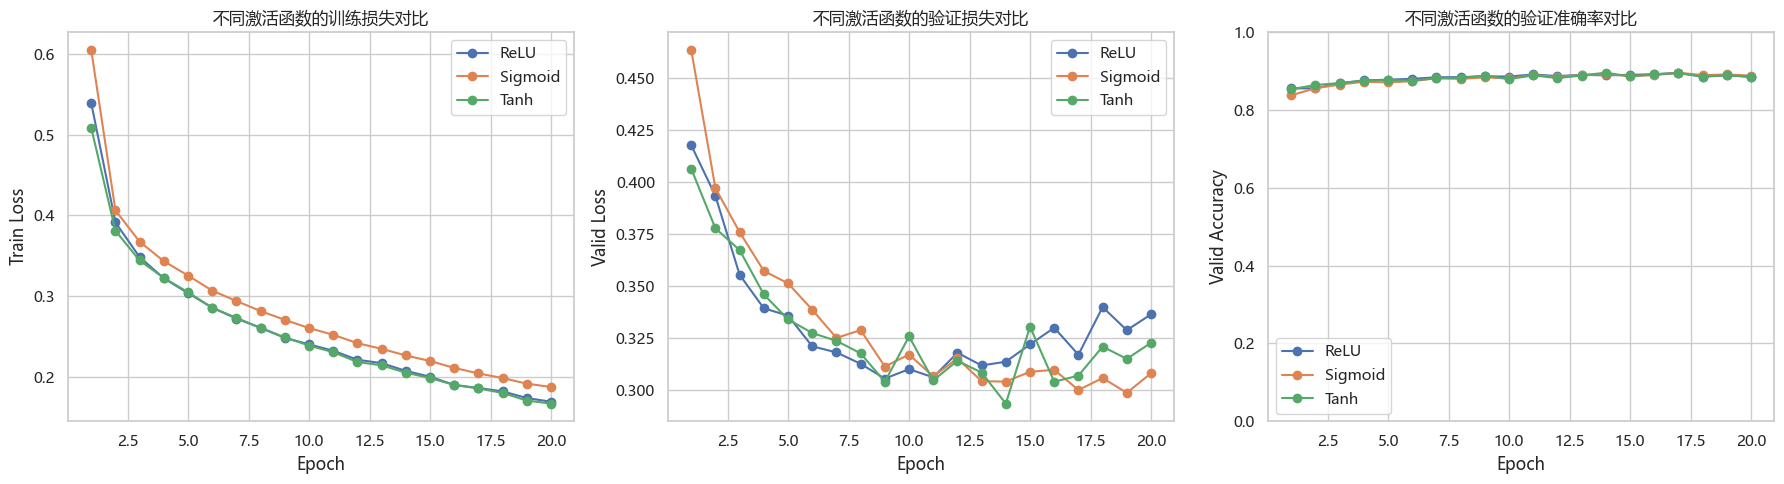

In [7]:
def plot_comparison(histories: dict[str, pd.DataFrame]) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for activation_name, history_df in histories.items():
        axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label=activation_name)
        axes[1].plot(history_df["epoch"], history_df["valid_loss"], marker="o", label=activation_name)
        axes[2].plot(history_df["epoch"], history_df["valid_accuracy"], marker="o", label=activation_name)

    axes[0].set_title("不同激活函数的训练损失对比")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train Loss")
    axes[0].legend()

    axes[1].set_title("不同激活函数的验证损失对比")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Valid Loss")
    axes[1].legend()

    axes[2].set_title("不同激活函数的验证准确率对比")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Valid Accuracy")
    axes[2].set_ylim(0, 1.0)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_comparison(histories)


## 实验小结

任务二完成后，你在写实验分析时可以重点回答这几个问题：

1. 三种激活函数中，哪一种前期收敛最快？
2. 哪一种在验证集上的最高准确率最高？
3. 哪一种曲线更平滑，训练过程更稳定？
4. Sigmoid 和 Tanh 与 ReLU 相比，各自有什么优缺点？

一般来说：

- ReLU 收敛往往更快
- Sigmoid 前期可能下降较慢
- Tanh 可能介于两者之间

但最后结论还是要以你这次跑出来的实验结果为准。
